In [1]:
import av
import os
import torch
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from transformers import AutoImageProcessor, VideoMAEForVideoClassification, set_seed, VideoMAEForPreTraining
from huggingface_hub import hf_hub_download

/home/firdavs/miniconda3/envs/firdavs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    set_seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Set seed: {seed}")

set_all_seeds(seed)

device: cuda
Set seed: 0


## Helper functions

In [3]:
def read_video_pyav(container, indices):
    '''
    Decode the video with PyAV decoder.
    Args:
        container (`av.container.input.InputContainer`): PyAV container.
        indices (`List[int]`): List of frame indices to desrc.
    Returns:
        result (np.ndarray): np array of decoded frames of shape (num_frames, height, width, 3).
    '''
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            frames.append(frame)
    return np.stack([x.to_ndarray(format="rgb24") for x in frames])


def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
    '''
    Sample a given number of frame indices from the video.
    Args:
        clip_len (`int`): Total number of frames to sample.
        frame_sample_rate (`int`): Sample every n-th frame.
        seg_len (`int`): Maximum allowed index of sample's last frame.
    Returns:
        indices (`List[int]`): List of sampled frame indices
    '''
    converted_len = int(clip_len * frame_sample_rate)
    end_idx = np.random.randint(converted_len, seg_len)
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx - 1).astype(np.int64)
    return indices

def display_video(file_path, title="Video Playback", delay=0.1, max_frames=None):
    # Open a fresh container
    container = av.open(file_path)
    video_stream = container.streams.video[0]
    
    frame_count = 0
    
    try:
        for frame in container.decode(video_stream):
            img = frame.to_ndarray(format='rgb24')
            
            plt.figure(figsize=(10, 8))
            plt.imshow(img)
            plt.title(title, fontsize=16)
            plt.axis('off')
            display(plt.gcf())
            plt.close()
            
            time.sleep(delay)
            clear_output(wait=True)
            
            frame_count += 1
            if max_frames and frame_count >= max_frames:
                break
    finally:
        container.close()

## Sample videos

In [4]:
file_path_spaghetti = hf_hub_download(
    repo_id="nielsr/video-demo", filename="eating_spaghetti.mp4", repo_type="dataset"
)

dir_path = '/home/firdavs/CholecT45'
video_name = 'VID01'
data_dir = os.path.join(dir_path, 'data', video_name)
file_path_cholec_example = os.path.join('../data/CholecT45-related/videos', video_name + '.avi')

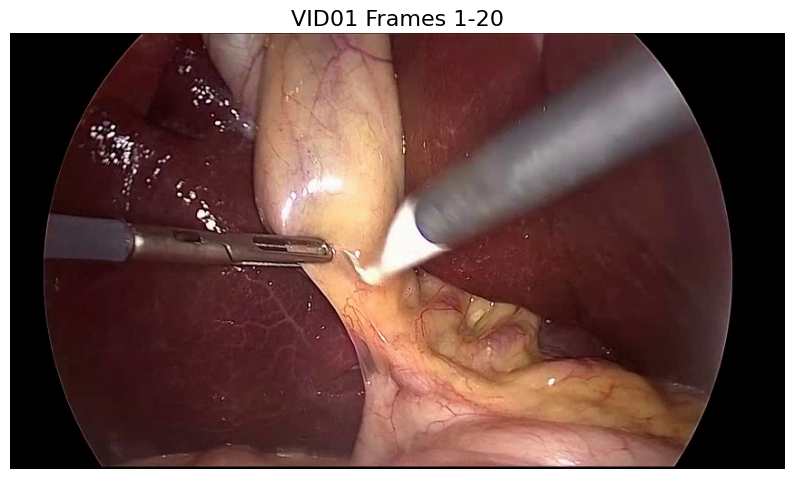

In [5]:
display_video(file_path_cholec_example, title="VID01 Frames 1-20", delay=0.05, max_frames=100)

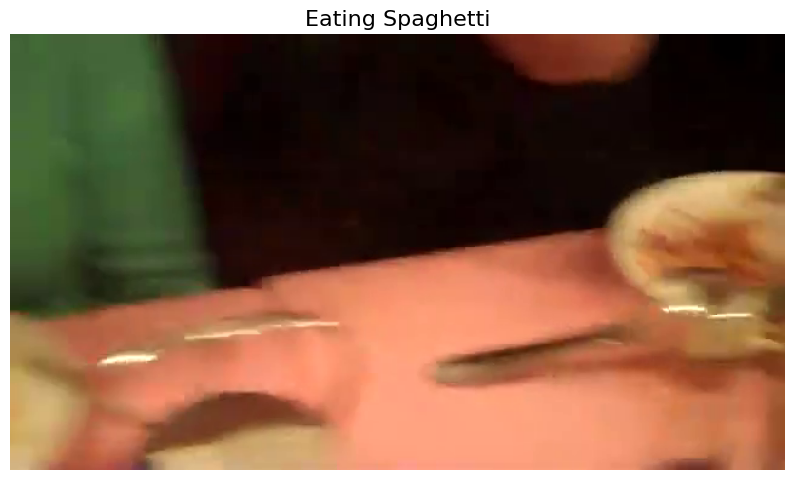

In [6]:
display_video(file_path_spaghetti, title="Eating Spaghetti", delay=0.001, max_frames=100)

In [7]:
container = av.open(file_path_spaghetti)
indices = sample_frame_indices(clip_len=16, frame_sample_rate=1, seg_len=container.streams.video[0].frames)
video = read_video_pyav(container, indices)

In [3]:
image_processor = AutoImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
model

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAESdpaAttention(
            (attention): VideoMAESdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (den

In [9]:
inputs = image_processor(list(video), return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# model predicts one of the 400 Kinetics-400 classes
predicted_label = logits.argmax(-1).item()
print(model.config.id2label[predicted_label])

eating spaghetti


In [10]:
inputs.keys()

dict_keys(['pixel_values'])

In [5]:
import torch
from transformers import VideoMAEConfig, VideoMAEForPreTraining

config = VideoMAEConfig(num_channels=3, image_size=224, patch_size=16, tubelet_size=2)
model = VideoMAEForPreTraining(config).to('cuda')
pixel_values = torch.randn(4, 16, 3, 224, 224).to('cuda')
# bool_masked_pos = (torch.rand(4, 1568).to('cuda') < 0.75)  # 1568 = (224//16)^2 * (16//2)

# assume the batch size is 2
num_frames = 16
num_patches_per_frame = (model.config.image_size // model.config.patch_size) ** 2
seq_length = (num_frames // model.config.tubelet_size) * num_patches_per_frame

bool_masked_pos_1 = torch.randint(0, 2, (1, seq_length)).bool()
bool_masked_pos_2 = torch.randint(0, 2, (1, seq_length)).bool()
bool_masked_pos = torch.cat([bool_masked_pos_1, bool_masked_pos_2])

print(bool_masked_pos.shape)
try:
    outputs = model(pixel_values, bool_masked_pos=bool_masked_pos)
    print("Model processed input successfully.")
except Exception as e:
    print(f"Error encountered: {e}")

torch.Size([2, 1568])
Error encountered: The shape of the mask [2, 1568] at index 0 does not match the shape of the indexed tensor [4, 1568, 768] at index 0


In [19]:
from transformers import VideoMAEFeatureExtractor, VideoMAEForPreTraining
import torch

model = VideoMAEForPreTraining.from_pretrained("MCG-NJU/videomae-base")

# assume the batch size is 2
num_frames = 16
num_batches = 2
pixel_values = torch.randn(num_batches,num_frames,3,224,224)

num_patches_per_frame = (model.config.image_size // model.config.patch_size) ** 2
seq_length = (num_frames // model.config.tubelet_size) * num_patches_per_frame

# bool_masked_pos = []
# for i in range(num_batches):
#     bool_masked_pos.append(torch.randint(0, 2, (1, seq_length)).bool())
# bool_masked_pos = torch.cat(bool_masked_pos)

bool_masked_pos_1 = torch.randint(0, 2, (1, seq_length)).bool()
bool_masked_pos_2 = torch.randint(0, 2, (1, seq_length)).bool()
bool_masked_pos = torch.cat([bool_masked_pos_1, bool_masked_pos_2])

outputs = model(pixel_values, bool_masked_pos=bool_masked_pos)

RuntimeError: shape '[2, -1, 768]' is invalid for input of size 1185024

In [28]:
from transformers import VideoMAEFeatureExtractor, VideoMAEForPreTraining
import torch
import math
import numpy as np

model = VideoMAEForPreTraining.from_pretrained("MCG-NJU/videomae-base")

# assume the batch size is 2
num_frames = 16
pixel_values = torch.randn(2,num_frames,3,224,224)

num_patches_per_frame = (model.config.image_size // model.config.patch_size) ** 2
seq_length = (num_frames // model.config.tubelet_size) * num_patches_per_frame

# bool_masked_pos_1 = torch.randint(0, 2, (1, seq_length)).bool()
# bool_masked_pos_2 = torch.randint(0, 2, (1, seq_length)).bool()
# bool_masked_pos = torch.cat([bool_masked_pos_1, bool_masked_pos_2])

batch_size = 2
mask_ratio = 0.75
bool_masked_pos = np.ones(seq_length)
mask_num = math.ceil(seq_length * mask_ratio)
mask = np.random.choice(seq_length, mask_num, replace=False)
bool_masked_pos[mask] = 0

# Torch and bool cast, extra dimension added for concatenation
bool_masked_pos = torch.as_tensor(bool_masked_pos).bool().unsqueeze(0)
bool_masked_pos = torch.cat([bool_masked_pos for _ in range(batch_size)])

outputs = model(pixel_values, bool_masked_pos=bool_masked_pos)

loss = outputs.loss

In [27]:
print(bool_masked_pos.shape)

torch.Size([2, 1568])
